In [122]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [123]:
# Set the root path as if it's being ran from the project root
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.append(project_root)

In [124]:
import pygad
import numpy as np
import torch
import os
from ga.components.fitness import constrained_fitness_func
from ga.components.mutation import paper_style_mutation, random_float_mutation, custom_mutation
from ga.components.crossover import pixel_cleaning_operation
from ga.components.model import load_model, evaluate_without_perturbation, evaluate_with_perturbation
from ga.utils import get_dataloader, visualize_images_batch,visualize_image, visualize_perturbation, compute_pixel_statistics, load_config

In [125]:
# Use GPU instead of CPU

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Parameters

In [152]:
config = load_config()

In [127]:
# num_generations =num_generations=config["ga"]["num_generations"]
# num_parents_mating=config["ga"]["num_parents_mating"]
# sol_per_pop=config["ga"]["sol_per_pop"]
# init_range_low=config["ga"]["init_range_low"]
# init_range_high=config["ga"]["init_range_high"]
# mutation_percent_genes=config["ga"]["mutation_percent_genes"]

# model_type = config["model"]["model_type"]
# batch_size = config["model"]["batch_size"]

# visualize = config["visualization"]["visualize"]
# visualize_every = config["visualization"]["visualize_every"]


# Model

In [153]:
model = load_model(config["model"]["model_type"], device=device)

Loading model: googlenet
Using device: mps


# Loading

In [129]:
# Load
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
image_dir = os.path.join(project_root, "nn/data/imagenet/val")
dataloader = get_dataloader(config["model"]["batch_size"], image_dir)


## Compute statistics - no need to run now

In [130]:
# Compute the pixel mean and standard deviation for each pixel across the entire dataset - for constrained fitness func

# pixel_mean, pixel_std = compute_pixel_statistics(dataloader)

# Roughly 0.04, 1.18, since we already normalize the dataset

In [131]:
# First batch
input_batch, labels = next(iter(dataloader))
input_batch, labels = input_batch.to(device), labels.to(device)

# Collect top perturbations from each generation
top_perturbations = []

# GA Config

In [132]:
def fitness_wrapper(ga_instance, solution, solution_idx):
    return constrained_fitness_func(
        ga_instance, solution, solution_idx, model, input_batch, labels, config["fitness"]["pixel_constraint_weight"], config["fitness"]["max_perturbation_magnitude"], config["fitness"]["epsilon_init"], config["fitness"]["epsilon_end"], config["fitness"]["penalty_factor"]
    )

In [133]:
def mutation_wrapper(offspring, ga_instance):

    return paper_style_mutation(offspring, ga_instance)
    # return custom_mutation(offspring, ga_instance, pixel_std, config["fitness"]["pixel_constraint_weight"], config["fitness"]["max_perturbation_magnitude"], input_batch, apply_pixel_constraints=False)

In [134]:
def on_crossover(ga_instance, offspring):
    # print("Number of zeros before pixel cleaning in crossover:", torch.sum(torch.tensor(offspring == 0)))
    offspring = pixel_cleaning_operation(offspring, cleaning_probability=config["crossover"]["pixel_cleaning_probability"])
    return offspring

In [135]:
def on_generation(ga_instance):

    print(f"\nGeneration {ga_instance.generations_completed} completed with fitness: {ga_instance.last_generation_fitness}")

    # print(f"Input batch starting label: {labels[0]}")

    # New batch every generation
    # input_batch, labels = next(iter(dataloader))
    # input_batch, labels = input_batch.to(device), labels.to(device)
    # print(f"New batch loaded with first label: {labels[0]}")
    
    # Print the best fitness for this generation
    best_solution, best_solution_fitness, _ = ga_instance.best_solution()
    print(f"Best Fitness = {best_solution_fitness}\n")

    # Possibly check partial genes in best solution
    snippet = best_solution[:10]
    print(f"Best solution snippet: {snippet}")

    num_zeros = np.count_nonzero(np.isclose(best_solution, 0.0))
    print(f"Best solution zeros count: {num_zeros}")

    # # Print out samples from the top 3 perturbations
    # top_fitness = sorted(ga_instance.last_generation_fitness)[-3:]
    # for i, perturbation in enumerate(top_fitness):
    #     print(f"Top {i+1} perturbation: {torch.norm(perturbation).item()}")

    best_perturbation = torch.tensor(best_solution).float().reshape(input_batch.shape[1:])
    top_perturbations.append(best_perturbation)
    print(f"Best perturbation magnitude: {torch.norm(best_perturbation).item()}")

    ########
    # VISUALIZATION
    ########
    if config["visualization"]["visualize"] and ga_instance.generations_completed % config["visualization"]["visualize_every"] == 0:
        print(f"Visualizing")
        # get the current best perturbation
        visualize_images_batch(input_batch, best_perturbation)

    # print(f"Generation {ga_instance.generations_completed}: Current Fitness: Best Fitness = {ga_instance.best_solution()[1]}")


Generation 1 completed with fitness: [-1.22984009 -1.24644318 -1.26033936 -1.26414642 -1.28153687 -1.27001038
 -1.23536377 -1.17825165 -1.24523926 -1.28026428 -1.24667664 -1.20641022
 -1.25190582 -1.24073944 -1.25704651 -1.24329376 -1.25636749 -1.27162476
 -1.26174316 -1.20671082 -1.28251038 -1.25495605 -1.25291748 -1.28286896
 -1.20801239 -1.21091003 -1.24259949 -1.20256348 -1.25339966 -1.25267639
 -1.22353821 -1.17104187 -1.22021484 -1.17617188 -1.28811035 -1.24020233
 -1.22344513 -1.2536087  -1.23930206 -1.27179565]
Best Fitness = -1.1710418701171876

Best solution snippet: [ 0.02732584 -0.37154309  0.14857398  0.45199923  0.44456779  0.4518896
  0.         -0.10844743 -0.37788862  0.20647394]
Best solution zeros count: 15189
Best perturbation magnitude: 105.93329620361328

Generation 2 completed with fitness: [-0.77081299 -0.79526367 -0.80089111 -0.75001678 -0.78419037 -0.75733643
 -0.76204071 -0.7941391  -0.7283783  -0.75291138 -0.78527832 -0.79937134
 -0.75325012 -0.78010101 -0.

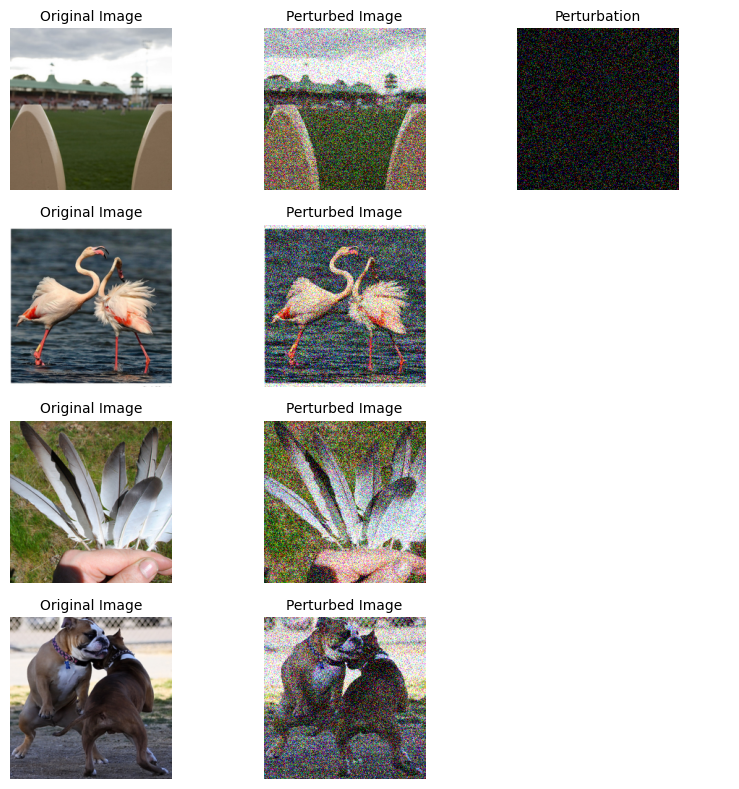


Generation 5 completed with fitness: [0.30632629 0.33960876 0.25228729 0.27197571 0.3757782  0.27549744
 0.31153412 0.33595123 0.41883087 0.31182251 0.24611969 0.26710815
 0.32732239 0.28618774 0.38303833 0.32580414 0.32149048 0.37475586
 0.3175415  0.33325195 0.29434357 0.30591583 0.32698975 0.29427338
 0.34334412 0.36096954 0.30403748 0.32156677 0.2864502  0.25305023
 0.31701813 0.3191452  0.28627777 0.32939148 0.39114532 0.32043762
 0.33164673 0.32471008 0.28166199 0.32126465]
Best Fitness = 0.41883087158203125

Best solution snippet: [ 0.          0.          0.          0.          0.          0.37304735
  0.         -0.10844743 -0.37788862  0.        ]
Best solution zeros count: 61788
Best perturbation magnitude: 85.6402359008789

Generation 6 completed with fitness: [0.50176239 0.51596832 0.65564728 0.50354462 0.54743347 0.6406723
 0.55301208 0.56819305 0.60111542 0.60573273 0.625      0.59628754
 0.52689972 0.58592072 0.54990234 0.56930389 0.5802887  0.53091736
 0.58595734 0.6

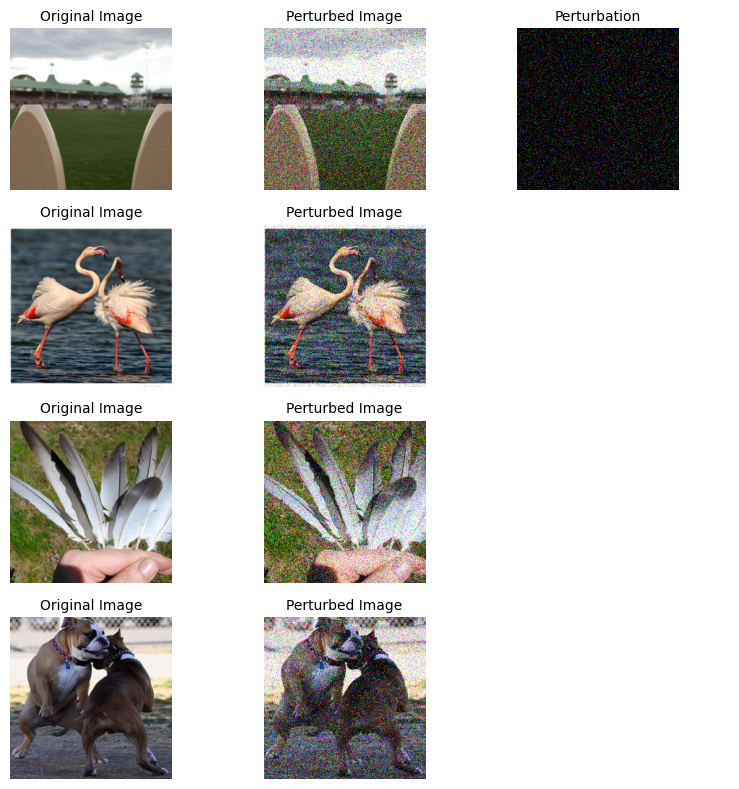


Generation 9 completed with fitness: [0.625    0.640625 0.640625 0.609375 0.59375  0.625    0.640625 0.609375
 0.640625 0.609375 0.625    0.671875 0.625    0.625    0.59375  0.625
 0.625    0.625    0.65625  0.640625 0.640625 0.625    0.609375 0.625
 0.609375 0.609375 0.609375 0.578125 0.5625   0.625    0.609375 0.640625
 0.609375 0.671875 0.65625  0.625    0.59375  0.625    0.640625 0.625   ]
Best Fitness = 0.671875

Best solution snippet: [ 0.         -0.06504333 -0.07720494  0.          0.01885024  0.
  0.          0.          0.          0.20647394]
Best solution zeros count: 91814
Best perturbation magnitude: 69.72600555419922

Generation 10 completed with fitness: [0.640625 0.59375  0.640625 0.640625 0.609375 0.609375 0.640625 0.640625
 0.640625 0.65625  0.640625 0.640625 0.625    0.625    0.640625 0.640625
 0.625    0.640625 0.625    0.625    0.609375 0.640625 0.640625 0.671875
 0.609375 0.625    0.640625 0.65625  0.640625 0.640625 0.640625 0.625
 0.609375 0.625    0.65625  0.6

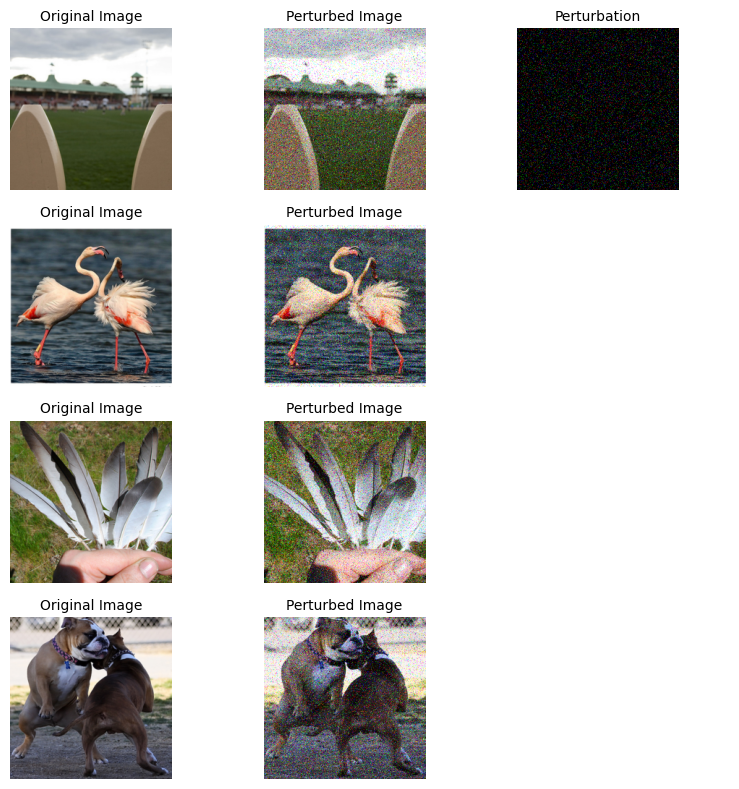


Generation 13 completed with fitness: [0.625    0.625    0.609375 0.59375  0.609375 0.640625 0.59375  0.609375
 0.59375  0.625    0.640625 0.640625 0.640625 0.640625 0.625    0.625
 0.609375 0.625    0.640625 0.609375 0.609375 0.625    0.625    0.640625
 0.59375  0.625    0.578125 0.625    0.609375 0.59375  0.578125 0.59375
 0.609375 0.59375  0.625    0.625    0.625    0.609375 0.609375 0.625   ]
Best Fitness = 0.640625

Best solution snippet: [ 0.         -0.06504333  0.          0.          0.          0.
 -0.4063398   0.01758431 -0.37788862  0.        ]
Best solution zeros count: 111807
Best perturbation magnitude: 56.80928421020508

Generation 14 completed with fitness: [0.625    0.640625 0.625    0.609375 0.609375 0.625    0.625    0.640625
 0.640625 0.640625 0.609375 0.609375 0.609375 0.59375  0.640625 0.625
 0.59375  0.59375  0.640625 0.609375 0.59375  0.625    0.640625 0.609375
 0.609375 0.59375  0.609375 0.609375 0.609375 0.609375 0.625    0.609375
 0.609375 0.625    0.609375

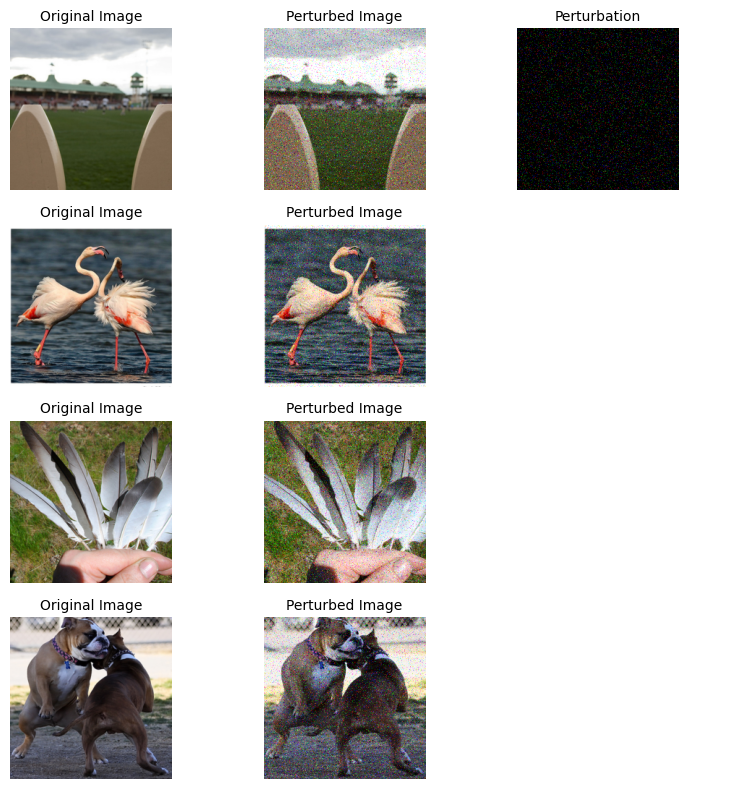

In [159]:
config = load_config()

ga_instance = pygad.GA(
    num_generations=config["ga"]["num_generations"],
    num_parents_mating=config["ga"]["num_parents_mating"],
    sol_per_pop=config["ga"]["sol_per_pop"],
    num_genes=3*224*224,
    gene_type=float,
    init_range_low=config["ga"]["init_range_low"],
    init_range_high=config["ga"]["init_range_high"],
    parent_selection_type=config["ga"]["parent_selection_type"],
    keep_elitism=config["ga"]["keep_elitism"],
    keep_parents=config["ga"]["keep_parents"],
    crossover_type=config["crossover"]["crossover_type"],
    crossover_probability=config["crossover"]["crossover_probability"],
    mutation_type=mutation_wrapper,
    # mutation_probability=config["ga"]["mutation_probability"],
    # mutation_percent_genes=config["ga"]["mutation_percent_genes"],
    fitness_func=fitness_wrapper,
    on_generation=on_generation,
    on_crossover=on_crossover,
)

ga_instance.run()

In [138]:
input_batch.shape

torch.Size([64, 3, 224, 224])

In [139]:
# After the run
solution, solution_fitness, _ = ga_instance.best_solution()
print(f"Best solution fitness: {solution_fitness}") # Might be the penultimate best fitness??

Best solution fitness: -1.8121788024902346


# Calculating Universal Perturbation

torch.Size([3, 224, 224])
Universal perturbation created.


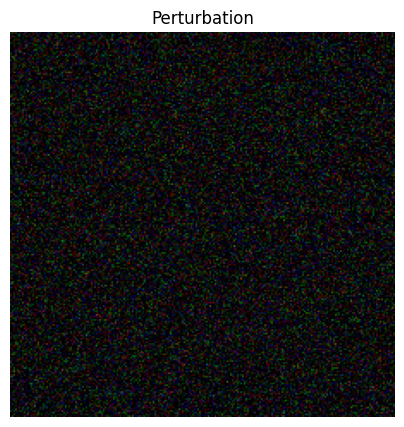

In [140]:
if len(top_perturbations) > 0:
    universal_perturbation = torch.mean(torch.stack(top_perturbations), dim=0)
    print(universal_perturbation.shape)
    print(f"Universal perturbation created.")
    visualize_perturbation(universal_perturbation)

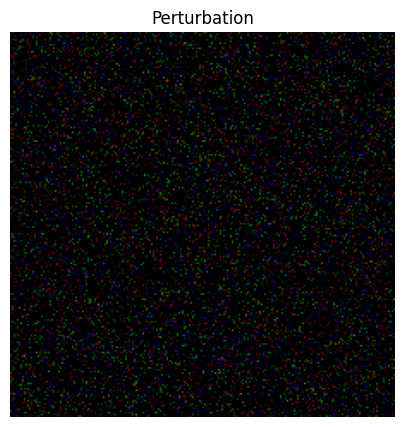

In [162]:
# Take the last one only (much smaller norm)
universal_perturbation = top_perturbations[-1]
visualize_perturbation(universal_perturbation)

# Metrics
(takes a while)

### GoogLeNet
(4 min)

In [155]:
evaluate_without_perturbation(model, dataloader, device)
# 0.6977

Using device: mps
Accuracy without perturbation: 0.69772


0.69772

In [161]:
evaluate_with_perturbation(model, dataloader, universal_perturbation, device)
# 9/24: 0.37964

# 12/24: 0.39556 (mean (higher norm)), 0.4017 (last one only)

Using device: mps
Accuracy with perturbation: 0.40172


0.40172

### ViT b 16

In [ ]:
evaluate_without_perturbation(model, dataloader, device)
# 0.811
# 13 mins

Using device: cpu


RuntimeError: Mismatched Tensor types in NNPack convolutionOutput

In [ ]:
evaluate_with_perturbation(model, dataloader, universal_perturbation, device)